In [1]:
# Google Colab Setup
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
    !pip install datasets sentencepiece
    from google.colab import drive
    drive.mount('/content/drive')
    # Optional: Change to your project directory if needed
    # import os
    # os.chdir('/content/drive/MyDrive/NLP/Project_A3/A3_Burmese_English_Puffer')
except ImportError:
    IN_COLAB = False
    print("Running Locally")

Running in Google Colab
Mounted at /content/drive


# Task 2: Experiment with Attention Mechanisms

**Student**: Htut Ko Ko  
**Course**: Natural Language Understanding  

## Objective
Implement a sequence-to-sequence neural network for the translation task and compare the performance of two attention mechanisms:
1. **General Attention (Dot Product)**: $e = s^T h_i$ (where $d_1 = d_2$)
2. **Additive Attention (Bahdanau)**: $e = v^T \tanh(W_1 h_i + W_2 s)$

We will use **Burmese-English (ALT Dataset)** for this experiment as it is the student's native language pair.

In [2]:
import os
import math
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
import sentencepiece as spm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Check for GPU
device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"Using device: {device}")

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

Using device: cuda


## 1. Data Loading (Burmese - ALT)

In [3]:
print("Loading ALT Dataset (Burmese-English)...")
try:
    dataset = load_dataset("alt", split="train+validation+test")
    data = []
    for item in dataset:
        if 'translation' in item:
            if 'my' in item['translation'] and 'en' in item['translation']:
                data.append({
                    'my': item['translation']['my'],
                    'en': item['translation']['en']
                })
    print(f"Extracted {len(data)} Burmese-English pairs.")
except Exception as e:
    print(f"Error loading from HF: {e}")

df = pd.DataFrame(data)
df = df.dropna()
df['my'] = df['my'].astype(str)
df['en'] = df['en'].astype(str)

Loading ALT Dataset (Burmese-English)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

alt-parallel/train-00000-of-00001.parque(…):   0%|          | 0.00/31.2M [00:00<?, ?B/s]

alt-parallel/validation-00000-of-00001.p(…):   0%|          | 0.00/1.71M [00:00<?, ?B/s]

alt-parallel/test-00000-of-00001.parquet:   0%|          | 0.00/1.79M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18088 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1019 [00:00<?, ? examples/s]

Extracted 20107 Burmese-English pairs.


## 2. Tokenization

In [4]:
# We will use existing trained tokenizers for Burmese and English (from previous tasks)
# Or retrain quickly if not found. Let's rely on creating them here to be self-contained.
with open('train_my_att.txt', 'w', encoding='utf-8') as f:
    for line in df['my']: f.write(line + '\n')

with open('train_en_att.txt', 'w', encoding='utf-8') as f:
    for line in df['en']: f.write(line + '\n')

vocab_size = 4000
spm.SentencePieceTrainer.train(input='train_my_att.txt', model_prefix='spm_my_att', vocab_size=vocab_size, model_type='bpe', pad_id=0, bos_id=1, eos_id=2, unk_id=3)
spm.SentencePieceTrainer.train(input='train_en_att.txt', model_prefix='spm_en_att', vocab_size=vocab_size, model_type='bpe', pad_id=0, bos_id=1, eos_id=2, unk_id=3)

sp_src = spm.SentencePieceProcessor(model_file='spm_my_att.model')
sp_trg = spm.SentencePieceProcessor(model_file='spm_en_att.model')

## 3. Seq2Seq Model with Attention

In [5]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, enc_hid_dim, bidirectional = True)
        self.fc = nn.Linear(enc_hid_dim * 2, dec_hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [src len, batch size]
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        # outputs = [src len, batch size, hid dim * num directions]
        # hidden = [n layers * num directions, batch size, hid dim]
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim = 1)))
        return outputs, hidden

class Attention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim, method='general'):
        super().__init__()
        self.method = method
        self.enc_hid_dim = enc_hid_dim
        self.dec_hid_dim = dec_hid_dim

        # Additive Attention Layers
        self.attn = nn.Linear((enc_hid_dim * 2) + dec_hid_dim, dec_hid_dim)
        self.v = nn.Linear(dec_hid_dim, 1, bias = False)

        # General Attention Layer
        self.general_attn = nn.Linear(enc_hid_dim * 2, dec_hid_dim)

    def forward(self, hidden, encoder_outputs):
        # hidden = [batch size, dec hid dim]
        # encoder_outputs = [src len, batch size, enc hid dim * 2]

        if self.method == 'general':
            # encoder_outputs: [src len, batch, enc_hid*2]
            # Permute for linear layer: [batch, src_len, enc_hid*2]
            encoder_outputs = encoder_outputs.permute(1, 0, 2)

            # Project to dec_hid_dim matching hidden: [batch, src_len, dec_hid]
            energy = self.general_attn(encoder_outputs)

            # hidden: [batch, dec_hid] -> [batch, dec_hid, 1]
            hidden = hidden.unsqueeze(2)

            # bmm: [batch, src_len, dec_hid] x [batch, dec_hid, 1] -> [batch, src_len, 1]
            attention = torch.bmm(energy, hidden).squeeze(2)
            return torch.softmax(attention, dim=1)

        elif self.method == 'additive':
            src_len = encoder_outputs.shape[0]
            hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
            encoder_outputs = encoder_outputs.permute(1, 0, 2)
            energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim = 2)))
            attention = self.v(energy).squeeze(2)
            return torch.softmax(attention, dim=1)

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU((enc_hid_dim * 2) + emb_dim, dec_hid_dim)
        self.fc_out = nn.Linear((enc_hid_dim * 2) + dec_hid_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))
        a = self.attention(hidden, encoder_outputs)
        a = a.unsqueeze(1)

        # For weighted sum, we need encoder_outputs as [batch, src_len, enc_hid*2]
        # If method was 'general', we permuted it inside attention, but here we need original shape or permuted
        # encoder_outputs passed here is [src_len, batch, enc_hid*2]
        encoder_outputs = encoder_outputs.permute(1, 0, 2)

        weighted = torch.bmm(a, encoder_outputs)
        weighted = weighted.permute(1, 0, 2)
        rnn_input = torch.cat((embedded, weighted), dim = 2)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)
        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim = 1))
        return prediction, hidden.squeeze(0), a.squeeze(1)

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio = 0.5):
        batch_size = src.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(src)
        input = trg[0, :]

        # Store attentions
        attentions = torch.zeros(trg_len, batch_size, src.shape[0]).to(self.device)

        for t in range(1, trg_len):
            output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
            outputs[t] = output
            attentions[t] = attention
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = trg[t, :] if teacher_force else top1
        return outputs, attentions

## 4. Training Loop

In [6]:
def train(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0
    for i, (src, trg) in enumerate(iterator):
        src, trg = src.to(device), trg.to(device)
        # Transpose for RNN: [src len, batch size]
        src = src.transpose(0, 1)
        trg = trg.transpose(0, 1)

        optimizer.zero_grad()
        output, _ = model(src, trg)
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        trg = trg[1:].reshape(-1)
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(iterator)

def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for i, (src, trg) in enumerate(iterator):
            src, trg = src.to(device), trg.to(device)
            src = src.transpose(0, 1)
            trg = trg.transpose(0, 1)
            output, _ = model(src, trg, 0) # No teacher forcing
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            trg = trg[1:].reshape(-1)
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(iterator)

## 5. Experiment Execution

In [7]:
class TranslationDataset(Dataset):
    def __init__(self, df, sp_src, sp_trg):
        self.data = df
        self.sp_src = sp_src
        self.sp_trg = sp_trg
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['my']
        trg_text = self.data.iloc[idx]['en']
        src_ids = [self.sp_src.bos_id()] + self.sp_src.encode(src_text, out_type=int) + [self.sp_src.eos_id()]
        trg_ids = [self.sp_trg.bos_id()] + self.sp_trg.encode(trg_text, out_type=int) + [self.sp_trg.eos_id()]
        return torch.tensor(src_ids), torch.tensor(trg_ids)

def collate_fn(batch):
    src_batch, trg_batch = [], []
    for src, trg in batch:
        src_batch.append(src)
        trg_batch.append(trg)
    src_pad = pad_sequence(src_batch, batch_first=True, padding_value=0)
    trg_pad = pad_sequence(trg_batch, batch_first=True, padding_value=0)
    return src_pad, trg_pad

dataset_full = TranslationDataset(df, sp_src, sp_trg)
train_size = int(0.8 * len(dataset_full))
valid_size = len(dataset_full) - train_size
train_data, valid_data = torch.utils.data.random_split(dataset_full, [train_size, valid_size])
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_data, batch_size=64, shuffle=False, collate_fn=collate_fn)

INPUT_DIM = vocab_size
OUTPUT_DIM = vocab_size
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
ENC_HID_DIM = 512
DEC_HID_DIM = 512
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

results = {}

for method in ['general', 'additive']:
    print(f"\nTraining with {method.upper()} Attention...")
    attn = Attention(ENC_HID_DIM, DEC_HID_DIM, method=method)
    enc = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, ENC_DROPOUT)
    dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DEC_DROPOUT, attn)
    model = Seq2Seq(enc, dec, device).to(device)

    optimizer = optim.Adam(model.parameters())
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    train_losses = []
    valid_losses = []

    for epoch in range(10): # 10 Epochs
        start_time = time.time()
        train_loss = train(model, train_loader, optimizer, criterion, 1)
        valid_loss = evaluate(model, valid_loader, criterion)
        end_time = time.time()

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)

        print(f'Epoch: {epoch+1:02} | Time: {end_time - start_time:.0f}s')
        print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
        print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

    results[method] = {
        'train_losses': train_losses,
        'valid_losses': valid_losses,
        'model': model
    }


Training with GENERAL Attention...
Epoch: 01 | Time: 89s
	Train Loss: 6.661 | Train PPL: 781.340
	 Val. Loss: 6.747 |  Val. PPL: 851.477
Epoch: 02 | Time: 89s
	Train Loss: 6.192 | Train PPL: 488.955
	 Val. Loss: 6.665 |  Val. PPL: 784.275
Epoch: 03 | Time: 89s
	Train Loss: 5.918 | Train PPL: 371.519
	 Val. Loss: 6.555 |  Val. PPL: 702.852
Epoch: 04 | Time: 89s
	Train Loss: 5.708 | Train PPL: 301.269
	 Val. Loss: 6.555 |  Val. PPL: 702.480
Epoch: 05 | Time: 88s
	Train Loss: 5.499 | Train PPL: 244.412
	 Val. Loss: 6.533 |  Val. PPL: 687.687
Epoch: 06 | Time: 88s
	Train Loss: 5.318 | Train PPL: 203.981
	 Val. Loss: 6.548 |  Val. PPL: 697.513
Epoch: 07 | Time: 89s
	Train Loss: 5.162 | Train PPL: 174.458
	 Val. Loss: 6.566 |  Val. PPL: 710.258
Epoch: 08 | Time: 88s
	Train Loss: 5.052 | Train PPL: 156.289
	 Val. Loss: 6.581 |  Val. PPL: 720.939
Epoch: 09 | Time: 88s
	Train Loss: 4.924 | Train PPL: 137.557
	 Val. Loss: 6.602 |  Val. PPL: 736.354
Epoch: 10 | Time: 89s
	Train Loss: 4.819 | Tra

## 6. Visualization & Comparison

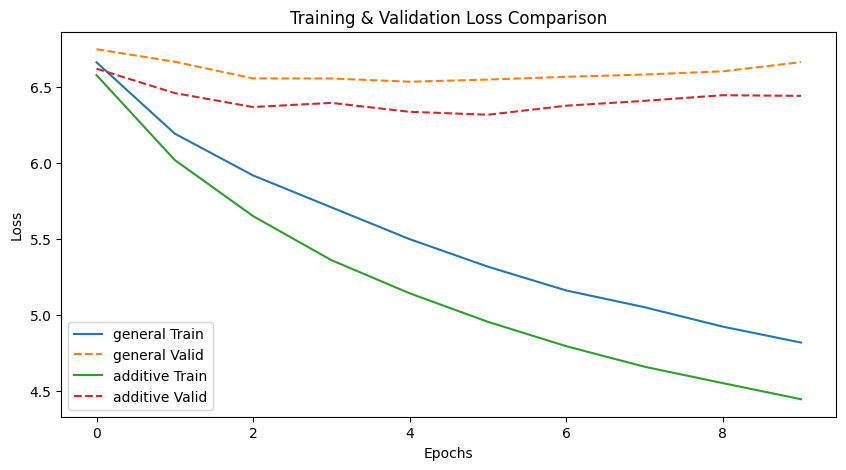

Source: ပြင်သစ်နိုင်ငံ ပါရီမြို့ ပါ့ဒက်စ် ပရင့်စက် ၌ ၂၀၀၇ခုနှစ် ရပ်ဘီ ကမ္ဘာ့ ဖလား တွင် အီတလီ သည် ပေါ်တူဂီ ကို ၃၁-၅ ဂိုး ဖြင့် ရေကူးကန် စီ တွင် ရှုံးနိမ့်သွားပါသည် ။
Target: Italy have defeated Portugal 31-5 in Pool C of the 2007 Rugby World Cup at Parc des Princes, Paris, France.

Method: general
Translation: The French defeated Port ug defeated Port ug defeated Port ug in Italy in Italy in Italy in Italy in Italy in the 2007 2007 2007 2007 in Italy , Italy , Italy , Italy Cup the 2007 . 


/tmp/ipython-input-463267404.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, rotation=45)
/tmp/ipython-input-463267404.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + translation)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4117 (\N{MYANMAR LETTER PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4156 (\N{MYANMAR CONSONANT SIGN MEDIAL RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4100 (\N{MYANMAR LETTER NGA}) missing from font(s) DejaVu Sans.
  fig.canvas.print

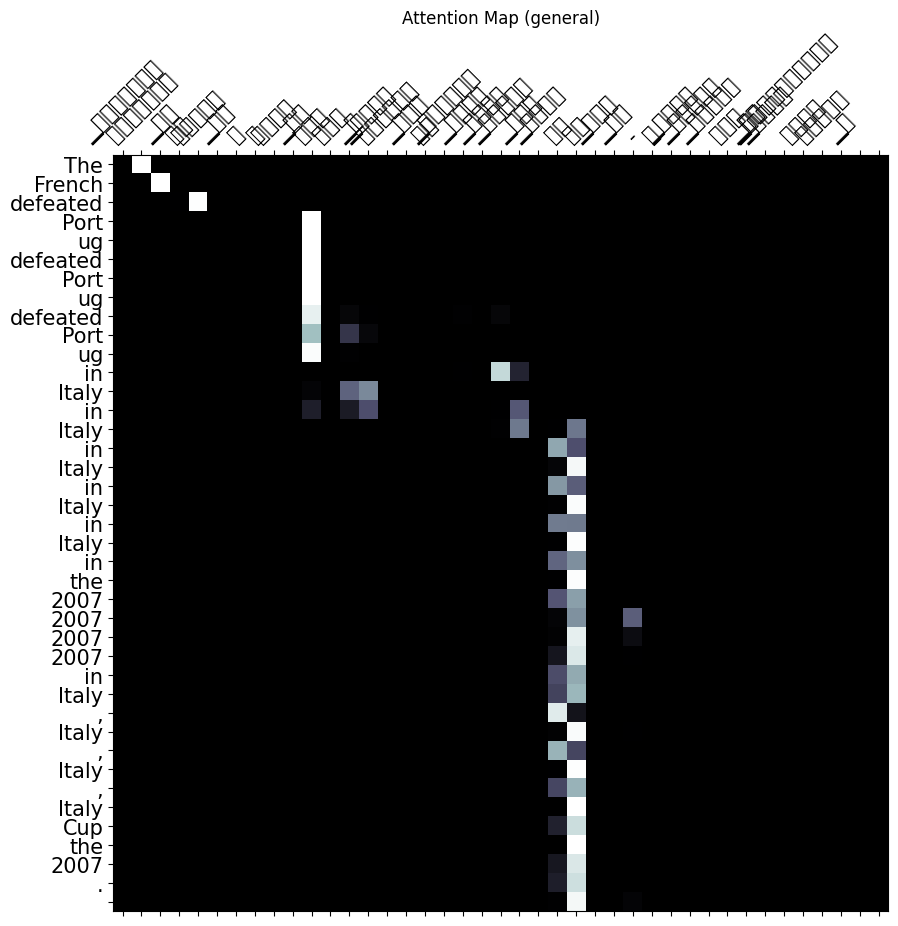


Method: additive
Translation: Italy defeated Port ug defeated Port ug Port ug Port ug in Port ug in Port ug in Port ug in Port ug Par as Port ug in France in France . 


/tmp/ipython-input-463267404.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, rotation=45)
/tmp/ipython-input-463267404.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + translation)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4117 (\N{MYANMAR LETTER PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4156 (\N{MYANMAR CONSONANT SIGN MEDIAL RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4100 (\N{MYANMAR LETTER NGA}) missing from font(s) DejaVu Sans.
  fig.canvas.print

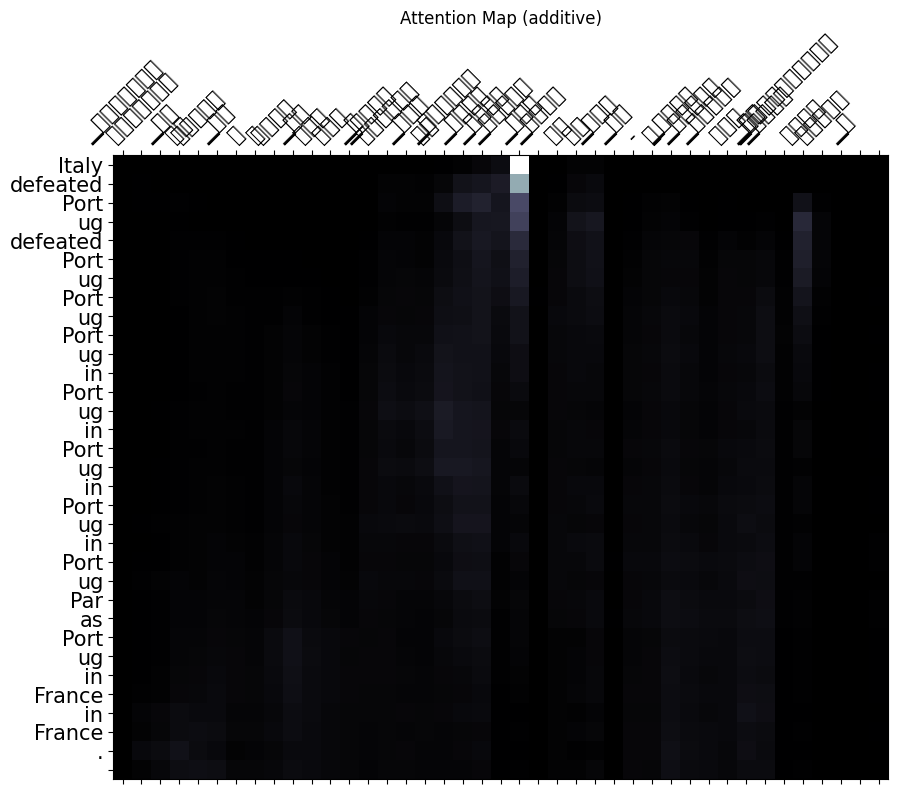

In [8]:
# Plot Losses
plt.figure(figsize=(10, 5))
for method in results:
    plt.plot(results[method]['train_losses'], label=f'{method} Train')
    plt.plot(results[method]['valid_losses'], label=f'{method} Valid', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss Comparison')
plt.savefig('attention_loss_comparison.png')
plt.show()

# Display Attention Maps
def display_attention(sentence, translation, attention, method_name):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)
    attention = attention.squeeze(1).cpu().detach().numpy()
    cax = ax.matshow(attention, cmap='bone')
    ax.tick_params(labelsize=15)
    ax.set_xticklabels([''] + sentence, rotation=45)
    ax.set_yticklabels([''] + translation)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    plt.title(f'Attention Map ({method_name})')
    plt.show()

def translate_sentence(sentence, model, device, max_len=50):
    model.eval()
    tokens = [sp_src.bos_id()] + sp_src.encode(sentence, out_type=int) + [sp_src.eos_id()]
    src_tensor = torch.LongTensor(tokens).unsqueeze(1).to(device)
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)
        attentions = torch.zeros(max_len, 1, len(tokens)).to(device)
        trg_indexes = [sp_trg.bos_id()]
        for i in range(max_len):
            trg_tensor = torch.LongTensor([trg_indexes[-1]]).to(device)
            output, hidden, attention = model.decoder(trg_tensor, hidden, encoder_outputs)
            attentions[i] = attention
            pred_token = output.argmax(1).item()
            trg_indexes.append(pred_token)
            if pred_token == sp_trg.eos_id():
                break
    trg_tokens = [sp_trg.decode([i]) for i in trg_indexes]
    return trg_tokens[1:], attentions[:len(trg_tokens)-1]

# Example Translation
example_idx = 0
src_text = df.iloc[example_idx]['my']
tgt_text = df.iloc[example_idx]['en']
print(f"Source: {src_text}")
print(f"Target: {tgt_text}")

for method in results:
    print(f"\nMethod: {method}")
    trans, attn = translate_sentence(src_text, results[method]['model'], device)
    print(f"Translation: {' '.join(trans)}")
    display_attention(sp_src.encode_as_pieces(src_text), trans, attn, method)

## 7. Results Table
Please copy the following table to your README.md.

In [9]:
print("Attentions          | Training Loss | Training PPL | Validation Loss | Validation PPL")
print("------------------------------------------------------------------------------------")
for method in results:
    tl = results[method]['train_losses'][-1]
    vl = results[method]['valid_losses'][-1]
    print(f"{method.title() + ' Attention':<20} | {tl:<13.3f} | {math.exp(tl):<12.3f} | {vl:<15.3f} | {math.exp(vl):<14.3f}")

Attentions          | Training Loss | Training PPL | Validation Loss | Validation PPL
------------------------------------------------------------------------------------
General Attention    | 4.819         | 123.868      | 6.662           | 782.166       
Additive Attention   | 4.447         | 85.368       | 6.440           | 626.673       
